In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings 
warnings.filterwarnings('ignore')

plt.style.use("seaborn-v0_8")

In [2]:
df = pd.read_csv("Google.csv", index_col = "Date", parse_dates = True)
df

,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,67.903809,67.942045,66.621583,66.621583,28132000
2020-01-03,67.570595,68.158574,66.819933,66.934945,23728000
2020-01-06,69.236694,69.350410,67.041216,67.041216,34646000
2020-01-07,69.193489,69.672708,69.046492,69.421929,30054000
2020-01-08,69.738762,70.099294,69.069339,69.130914,30560000
...,...,...,...,...,...
2025-10-22,252.529999,257.179993,250.451004,255.009995,19650200
2025-10-23,253.729996,255.860001,252.768005,253.699997,13241300
2025-10-24,260.510010,262.510010,256.100006,257.299988,18406000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1464 entries, 2020-01-02 to 2025-10-28
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1464 non-null   float64
 1   High    1464 non-null   float64
 2   Low     1464 non-null   float64
 3   Open    1464 non-null   float64
 4   Volume  1464 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 68.6 KB


In [4]:
df.describe()

,Close,High,Low,Open,Volume
count,1464.000000,1464.000000,1464.000000,1464.000000,1.464000e+03
mean,129.449628,130.865039,127.967850,129.339415,2.683920e+07
std,41.321163,41.654213,40.920301,41.279959,1.246213e+07
min,52.471924,53.201929,50.332364,52.466462,6.809800e+06
25%,98.620125,99.906316,97.132802,98.436374,1.862912e+07
50%,129.236595,130.928882,127.961817,129.464545,2.394200e+07
75%,156.660427,158.636521,155.028917,156.331293,3.153892e+07
max,269.929993,271.380005,267.170013,270.200012,9.779860e+07


In [5]:
df.isnull().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [6]:
price = df["Close"]

In [7]:
price.describe()

count    1464.000000
mean      129.449628
std        41.321163
min        52.471924
25%        98.620125
50%       129.236595
75%       156.660427
max       269.929993
Name: Close, dtype: float64

<Axes: title={'center': 'Google Share Price'}, xlabel='Date'>

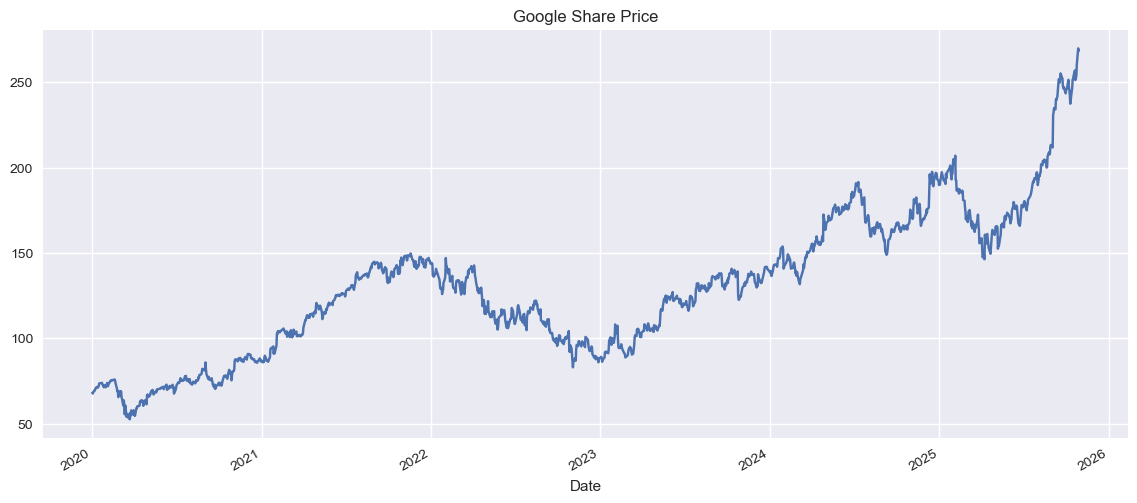

In [8]:
plt.figure(figsize=(14,6))
price.plot(title="Google Share Price")

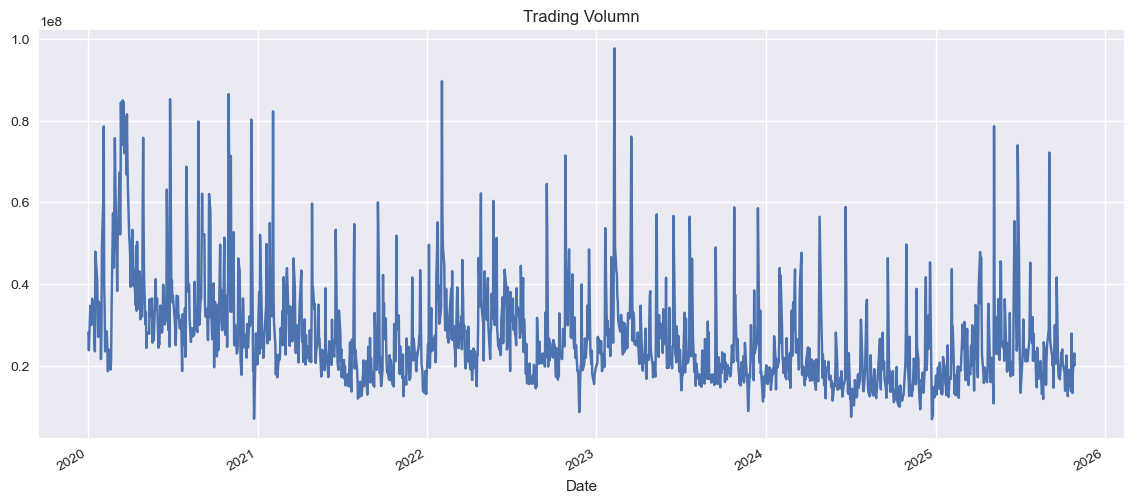

In [9]:
df["Volume"].plot(figsize=(14,6),title= "Trading Volumn")
plt.show()

### Correlation Between Closing price and the Volume

In [10]:
corr_1 = df[["Volume","Close"]].corr()
print(corr_1)

          Volume     Close
Volume  1.000000 -0.440723
Close  -0.440723  1.000000


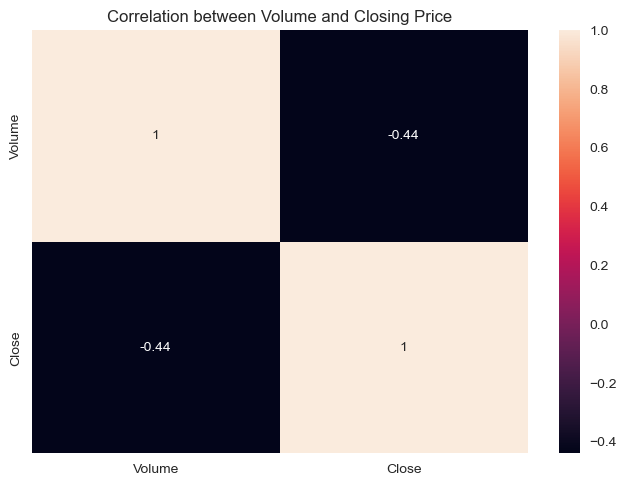

In [11]:
sns.heatmap(corr_1, annot=True)
plt.title('Correlation between Volume and Closing Price')
plt.show()

### Average yearly closing price

In [12]:
df['Year'] = df.index.year
yearly_avg = df.groupby('Year')['Close'].mean()
yearly_avg

Year
2020     73.566754
2021    124.677487
2022    114.410777
2023    118.798889
2024    164.348724
2025    192.477837
Name: Close, dtype: float64

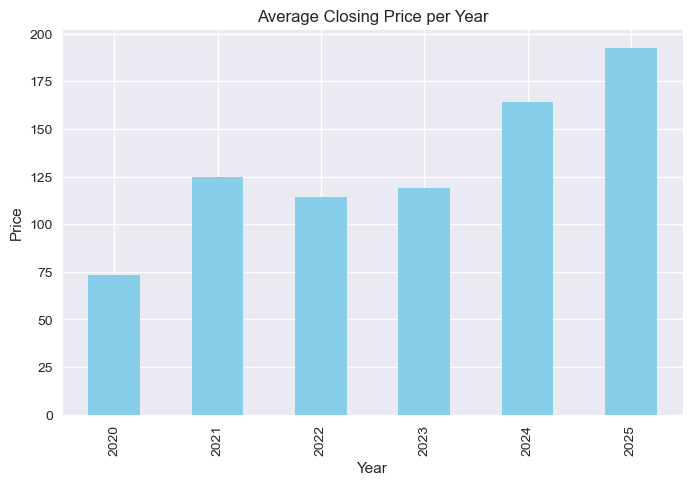

In [13]:
df['Year'] = df.index.year
yearly_avg = df.groupby('Year')['Close'].mean()
yearly_avg

### Year-end Closing Price

In [14]:
yearly_close = df.groupby('Year')['Close'].last()
print(yearly_close)

Year
2020     86.998650
2021    143.696152
2022     88.126923
2023    139.972138
2024    189.825241
2025    268.429993
Name: Close, dtype: float64


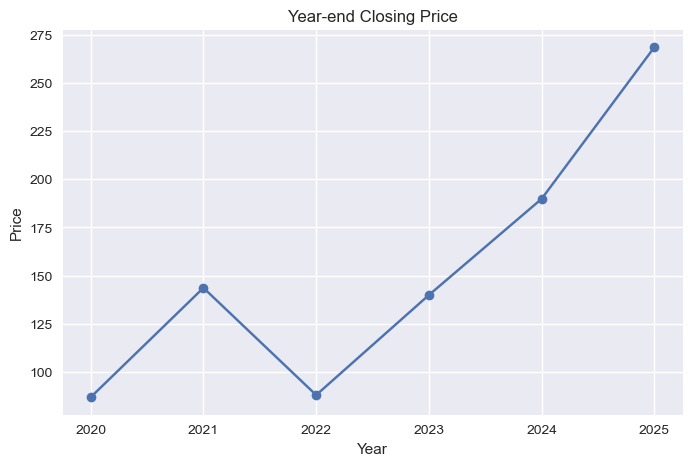

In [15]:
yearly_close.plot(kind='line', marker='o', figsize=(8,5))
plt.title('Year-end Closing Price')
plt.ylabel('Price')
plt.xlabel('Year')
plt.grid(True)
plt.show()

### Highest Closing Price per Year

In [16]:
yearly_max = df.groupby('Year')['Close'].max()
print(yearly_max)

Year
2020     90.778275
2021    149.684662
2022    147.030335
2023    141.849320
2024    197.520340
2025    269.929993
Name: Close, dtype: float64


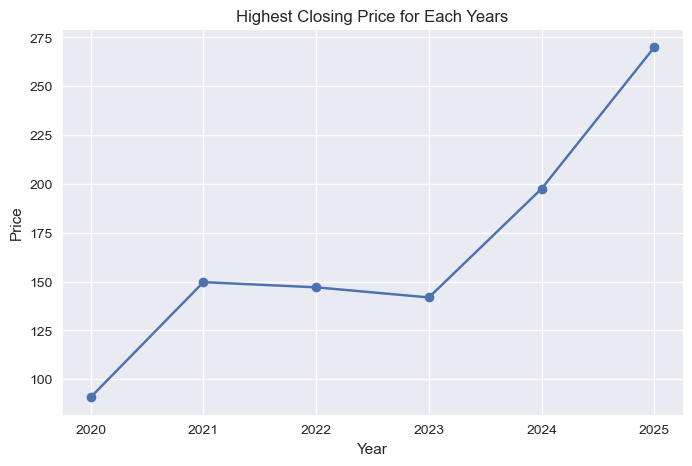

In [17]:
yearly_max.plot(kind='line', marker='o', figsize=(8,5))
plt.title('Highest Closing Price for Each Years')
plt.ylabel('Price')
plt.xlabel('Year')
plt.grid(True)
plt.show()

### Lowest Closing Price per Year

In [18]:
yearly_min = df.groupby('Year')['Close'].min()
print(yearly_min)

Year
2020     52.471924
2021     85.824684
2022     82.922539
2023     86.180244
2024    131.659027
2025    146.273285
Name: Close, dtype: float64


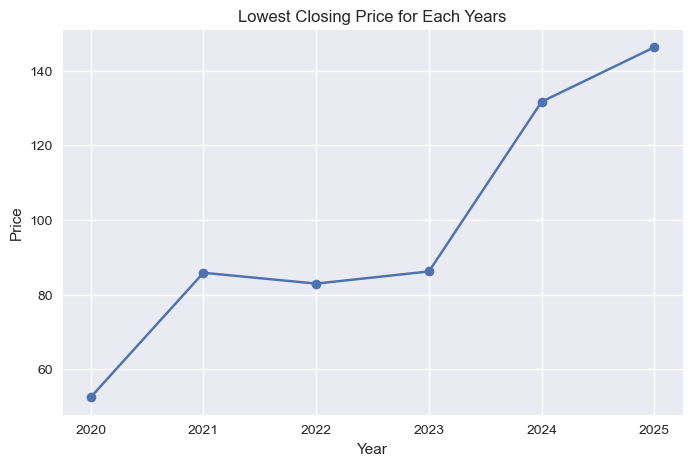

In [19]:
yearly_min.plot(kind='line', marker='o', figsize=(8,5))
plt.title('Lowest Closing Price for Each Years')
plt.ylabel('Price')
plt.xlabel('Year')
plt.grid(True)
plt.show()

In [20]:
df['Year'] = df.index.year
df['Month'] = df.index.month
monthly_stats = df.groupby(['Year', 'Month'])['Close'].agg(['max','min']).reset_index()
highest_month = monthly_stats.loc[monthly_stats.groupby('Year')['max'].idxmax()]
highest_month = highest_month[['Year','Month','max']]
highest_month.columns = ['Year','Month_with_Highest_Price','Highest_Price']
print(highest_month)

    Year  Month_with_Highest_Price  Highest_Price
11  2020                        12      90.778275
22  2021                        11     149.684662
25  2022                         2     147.030335
47  2023                        12     141.849320
59  2024                        12     197.520340
69  2025                        10     269.929993


In [21]:
lowest_month = monthly_stats.loc[monthly_stats.groupby('Year')['min'].idxmin()]
lowest_month = lowest_month[['Year','Month','min']]
lowest_month.columns = ['Year','Month_with_Lowest_Price','Lowest_Price']
print(lowest_month)

    Year  Month_with_Lowest_Price  Lowest_Price
2   2020                        3     52.471924
12  2021                        1     85.824684
34  2022                       11     82.922539
36  2023                        1     86.180244
50  2024                        3    131.659027
63  2025                        4    146.273285


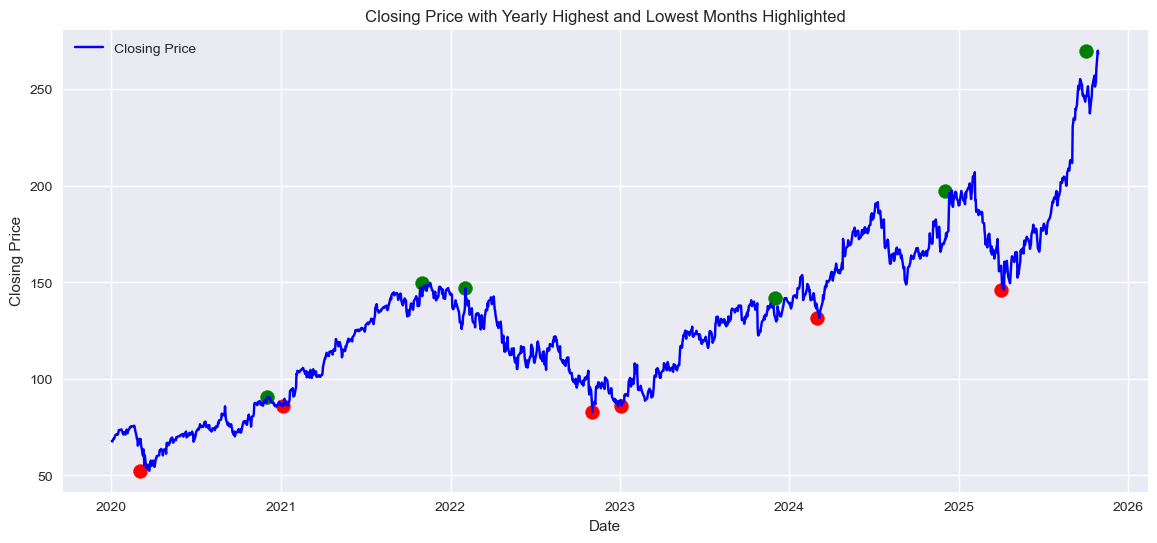

In [22]:
plt.figure(figsize=(14,6))
plt.plot(df.index, df['Close'], label='Closing Price', color='blue')
for _, row in highest_month.iterrows():
    date = df[(df.index.year==row['Year']) & (df.index.month==row['Month_with_Highest_Price'])].index[0]
    plt.scatter(date, row['Highest_Price'], color='green', s=100, label='Yearly High' if _==0 else "")
for _, row in lowest_month.iterrows():
    date = df[(df.index.year==row['Year']) & (df.index.month==row['Month_with_Lowest_Price'])].index[0]
    plt.scatter(date, row['Lowest_Price'], color='red', s=100, label='Yearly Low' if _==0 else "")
plt.title('Closing Price with Yearly Highest and Lowest Months Highlighted')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.grid(True)
plt.show()

### Correlation Between Years

In [23]:
df.index = pd.to_datetime(df.index)

df['DayOfYear'] = df.index.dayofyear
df['Year'] = df.index.year

pivot = df.pivot_table(values='Close', index='DayOfYear', columns='Year')
year_corr = pivot.corr()
print(year_corr)

Year      2020      2021      2022      2023      2024      2025
Year                                                            
2020  1.000000  0.709955 -0.736474  0.667884  0.541062  0.653631
2021  0.709955  1.000000 -0.882376  0.939677  0.686773  0.585386
2022 -0.736474 -0.882376  1.000000 -0.862487 -0.755535 -0.608774
2023  0.667884  0.939677 -0.862487  1.000000  0.701013  0.633567
2024  0.541062  0.686773 -0.755535  0.701013  1.000000  0.014010
2025  0.653631  0.585386 -0.608774  0.633567  0.014010  1.000000


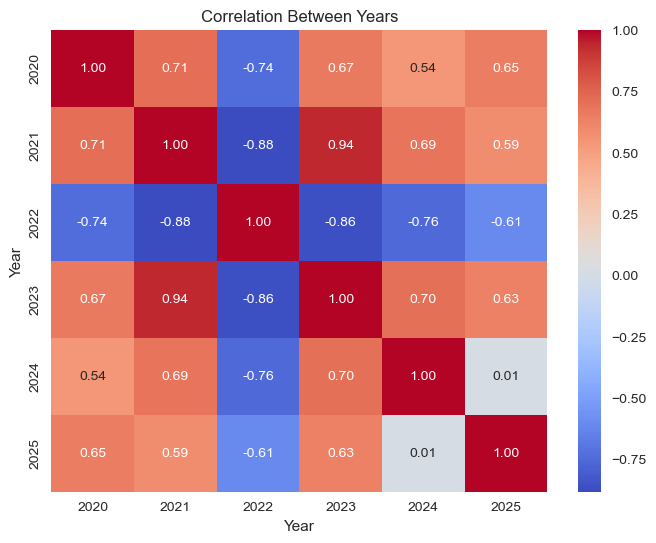

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(year_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Years')
plt.show()

### 1.1 Checking for Stationarity In The Share Price

In [25]:
def adf_test(series):
    result = adfuller(series)
    print("ADF Statistics:",result[0])
    print("p-value:", result[1])
    for key, value in result[4].items():
        print(f"Critical Values {key}:{value}")
    if result[1] < 0.05:
        print("There is stationarity (reject the H0)")
    else:
        print("The series is non-stationary(fail to reject the H0)")
print("\nADF Test on Original Series:")
adf_test(price)


ADF Test on Original Series:
ADF Statistics: 0.9561084429999888
p-value: 0.9937805607358741
Critical Values 1%:-3.434836872962171
Critical Values 5%:-2.863521656701378
Critical Values 10%:-2.567825016419591
The series is non-stationary(fail to reject the H0)


### 1.2 Finding Returns and First Differencing

In [26]:
price_return_diff = np.log(price).diff().dropna()

In [27]:
price_return_diff

Date
2020-01-03   -0.004919
2020-01-06    0.024358
2020-01-07   -0.000624
2020-01-08    0.007850
2020-01-09    0.010984
                ...   
2025-10-22    0.004723
2025-10-23    0.004741
2025-10-24    0.026371
2025-10-27    0.035521
2025-10-28   -0.005572
Name: Close, Length: 1463, dtype: float64

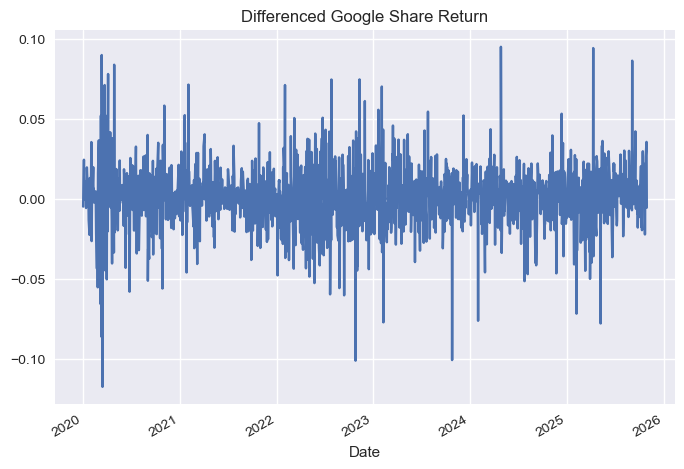

In [28]:
price_return_diff.plot(title = "Differenced Google Share Return")
plt.show()

### Correlation between Returns and Volume

In [29]:
corr = price_return_diff.corr(df['Volume'])
print(corr)

-0.04901620667751016


### 1.3 Checking for Stationarity After the First Differencing

In [30]:
adf_test(price_return_diff)

ADF Statistics: -12.238677967654974
p-value: 1.014258374050487e-22
Critical Values 1%:-3.4348554210983093
Critical Values 5%:-2.8635298424390276
Critical Values 10%:-2.5678293754552732
There is stationarity (reject the H0)


### 2.0 Using the ACF and PACF to Determine the Moving Average and Past Value

In [31]:
from statsmodels.tsa.arima.model import ARIMA

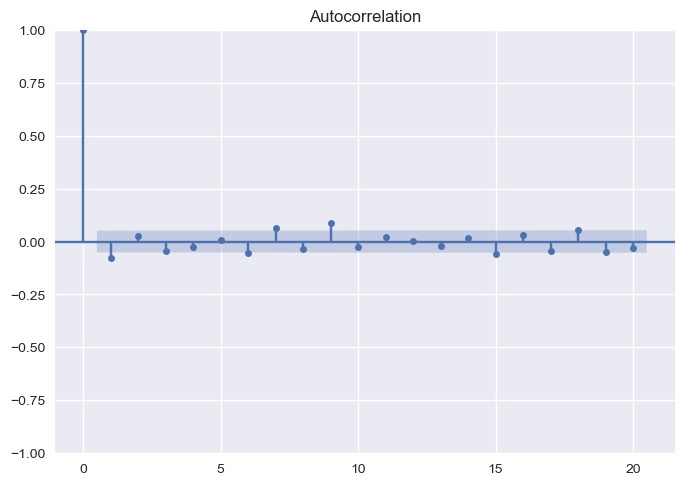

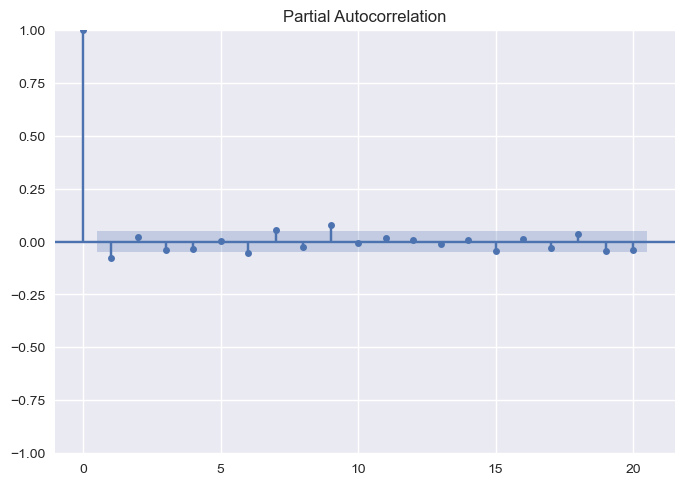

In [32]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(price_return_diff, lags=20)
plot_pacf(price_return_diff, lags=20)
plt.show()

### Per the acf and the pacf graph, the parameter to use is (1,1)

In [33]:
model = ARIMA(price, order=(1, 1, 1))
results = model.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1464
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -3458.385
Date:                Thu, 26 Mar 2026   AIC                           6922.770
Time:                        12:10:48   BIC                           6938.634
Sample:                             0   HQIC                          6928.687
                               - 1464                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6187      0.386     -1.604      0.109      -1.375       0.137
ma.L1          0.5898      0.394      1.496      0.135      -0.183       1.363
sigma2         6.6188      0.126     52.566      0.0

In [34]:
model_1 = ARIMA(price, order=(0, 1, 0))
results_1 = model_1.fit()
print(results_1.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1464
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -3459.373
Date:                Thu, 26 Mar 2026   AIC                           6920.745
Time:                        12:10:48   BIC                           6926.033
Sample:                             0   HQIC                          6922.718
                               - 1464                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         6.6278      0.123     53.808      0.000       6.386       6.869
Ljung-Box (L1) (Q):                   0.88   Jarque-Bera (JB):              2139.65
Prob(Q):                              0.35   Pr

In [35]:
model_2 = ARIMA(price, order=(1, 1, 0))
results_2 = model_2.fit()
print(results_2.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1464
Model:                 ARIMA(1, 1, 0)   Log Likelihood               -3459.031
Date:                Thu, 26 Mar 2026   AIC                           6922.062
Time:                        12:10:48   BIC                           6932.639
Sample:                             0   HQIC                          6926.007
                               - 1464                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0216      0.022     -0.982      0.326      -0.065       0.022
sigma2         6.6247      0.125     52.997      0.000       6.380       6.870
Ljung-Box (L1) (Q):                   0.01   Jarque-

In [36]:
model_3 = ARIMA(price, order=(0, 1, 1))
results_3 = model_3.fit()
print(results_3.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1464
Model:                 ARIMA(0, 1, 1)   Log Likelihood               -3459.041
Date:                Thu, 26 Mar 2026   AIC                           6922.082
Time:                        12:10:49   BIC                           6932.659
Sample:                             0   HQIC                          6926.027
                               - 1464                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0210      0.022     -0.953      0.341      -0.064       0.022
sigma2         6.6248      0.125     53.044      0.000       6.380       6.870
Ljung-Box (L1) (Q):                   0.02   Jarque-

In [37]:
model_4 = ARIMA(price, order=(2, 1, 1))
results_4 = model_4.fit()
print(results_4.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1464
Model:                 ARIMA(2, 1, 1)   Log Likelihood               -3458.184
Date:                Thu, 26 Mar 2026   AIC                           6924.367
Time:                        12:10:50   BIC                           6945.520
Sample:                             0   HQIC                          6932.257
                               - 1464                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5119      0.516     -0.992      0.321      -1.523       0.500
ar.L2          0.0191      0.032      0.588      0.557      -0.044       0.083
ma.L1          0.4915      0.514      0.957      0.3

In [38]:
model_5 = ARIMA(price, order=(1, 1, 2))
results_5 = model_5.fit()
print(results_5.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1464
Model:                 ARIMA(1, 1, 2)   Log Likelihood               -3458.612
Date:                Thu, 26 Mar 2026   AIC                           6925.225
Time:                        12:10:51   BIC                           6946.378
Sample:                             0   HQIC                          6933.115
                               - 1464                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6346      0.570      1.112      0.266      -0.484       1.753
ma.L1         -0.6573      0.569     -1.155      0.248      -1.773       0.458
ma.L2         -0.0034      0.035     -0.097      0.9

### 3.0 Fitting the Model

### 3.2 Forecasting

 Based on the BIC assumption, the best model to use is the one with the lowest BIC; therefore the best model with the lowest BIC is result_1 ie.(0,1,0)

In [39]:
forecast = results_1.forecast(steps=30)

future_index = pd.date_range(start=df.index[-1], periods=30+1, freq="B")[1:]
forecast.index = future_index

print(forecast.head())

2025-10-29    268.429993
2025-10-30    268.429993
2025-10-31    268.429993
2025-11-03    268.429993
2025-11-04    268.429993
Freq: B, Name: predicted_mean, dtype: float64


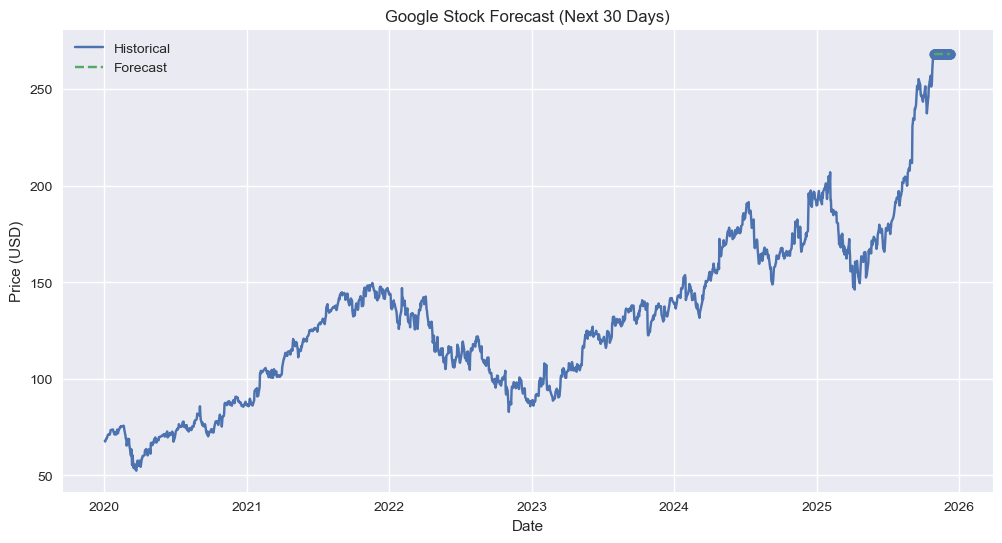

In [44]:
plt.figure(figsize=(12, 6))
plt.plot(price, label="Historical")
plt.plot(forecast, label="Forecast", linestyle="--")
plt.scatter(forecast.index, forecast, s=50)
plt.title("Google Stock Forecast (Next 30 Days)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

### 3.1 Ploting the Residual

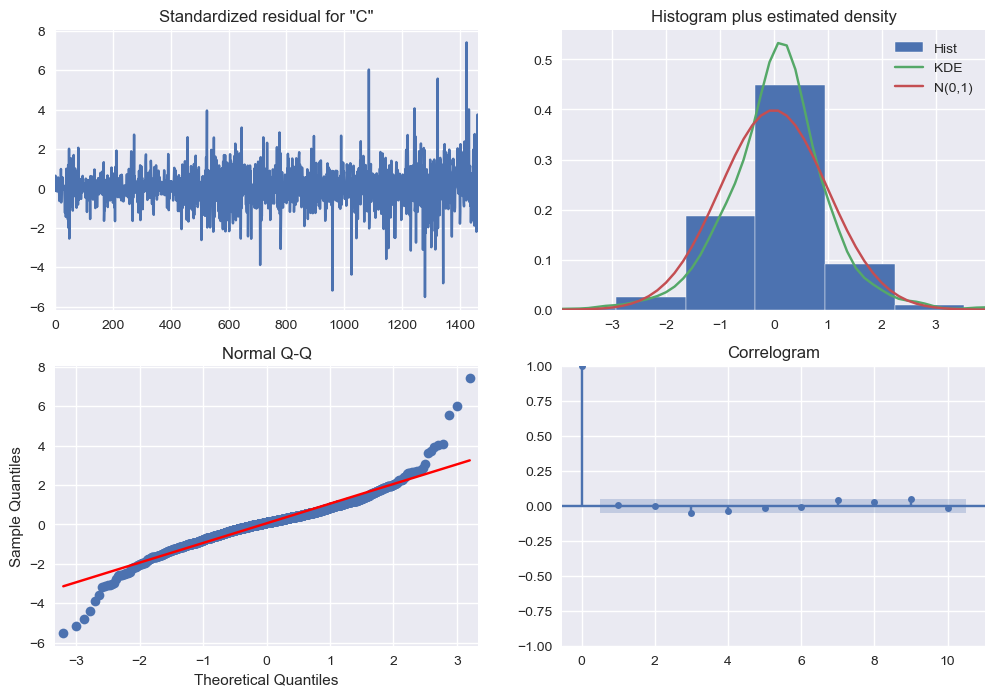

In [41]:
results.plot_diagnostics(figsize=(12, 8))
plt.show()

In [42]:
train = price[:-90]
test = price[-90:]

model_bt = ARIMA(train, order=(0,1,0)).fit()
pred = model_bt.forecast(steps=90)

mae = mean_absolute_error(test, pred)
rmse = np.sqrt(mean_squared_error(test, pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 49.153806175555545
RMSE: 57.49378120412673


In [43]:
rmse/test.mean()

np.float64(0.2653201966531484)